# Chapter 16 (Exercise Solution) — Chapter 11 Capstone: Carbon-Constrained Bond Portfolio Optimization

Port of `chap16_chap11_exercise1.m`, the exercise solution for Chapter 11
(Fixed-Income Portfolio Optimization). An 8-asset bond portfolio benchmark
is analyzed for carbon intensity (Scope 1/2/3), then a sequence of
tracking-error-minimizing and mixed active-share/duration/spread-risk
portfolios are built under carbon-reduction budget constraints.

This notebook reuses (in slightly adapted, self-contained form) the exact
machinery already built and verified in `11a_tracking_error_optimization_basics`,
`11b_l1_l2_norm_reformulation`, and `11c_quadratic_form_verification`:
`xpnd`, a tracking-error-minimizing QP wrapper, `quadratic_form_bond_portfolio2`
and friends, and the L1 mixed-norm solver. Rather than re-deriving an
approximate SLSQP-based QP solver as `11a` did, the QP-structured questions
here (2.d-g, 3.c-e, 3.g) call `quanttoolbox.optim.quadprog.solve_qp` directly
-- an exact convex QP solver (via `cvxpy`) that was not yet exposed as a
reusable primitive when `11a` was built, and matches MATLAB's `quadprog`
convention (`0.5*x'Qx - R'x`) exactly, so `Q`/`R` pairs built by
`quadratic_form_bond_portfolio2` plug straight in with no sign conversion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog

from quanttoolbox.optim.quadprog import solve_qp

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.float_format", lambda v: f"{v: .6f}")

color_blue = "#1f77b4"
color_red = "#d62728"
color_green = "#2ca02c"
color_violet = "#ff33ff"
color_black = "#000000"
color_teal = "#17becf"

rng = np.random.default_rng(0)  # unused (no randomness in this exercise) -- kept for house consistency


## Reused helper functions

Self-contained re-implementations of the Chapter 11 machinery this exercise
calls (kept local to this notebook rather than imported, per this project's
one-notebook-per-file convention).

In [2]:
def xpnd(rho_vec, n):
    '''Expand a lower-triangular-packed vector (row-major, incl. diagonal)
    into a symmetric n x n matrix -- port of QuantToolbox's xpnd (from 11a).'''
    M = np.zeros((n, n))
    k = 0
    for i in range(n):
        for j in range(i + 1):
            M[i, j] = M[j, i] = rho_vec[k]
            k += 1
    return M


def te_min_portfolio(b, Sigma, A_eq, b_eq, A_ub=None, b_ub=None, lb=None, ub=None):
    '''Port of compute_te_portfolio's gamma=0 (pure minimum-tracking-error)
    case: minimizes (x-b)'Sigma(x-b) subject to A_eq x = b_eq, A_ub x <= b_ub,
    lb <= x <= ub. Expanded to solve_qp's 0.5*x'Qx - R'x form: Q=2*Sigma,
    R=2*Sigma@b (the b'Sigma*b constant term does not affect the argmin).'''
    b = np.asarray(b, dtype=float)
    n = len(b)
    lb = np.zeros(n) if lb is None else lb
    ub = np.ones(n) if ub is None else ub
    Q = 2 * Sigma
    R = 2 * Sigma @ b
    x = solve_qp(Q, R, a_eq=A_eq, b_eq=b_eq, c_ineq=A_ub, d_ineq=b_ub, lb=lb, ub=ub)
    sigma_x = np.sqrt(max((x - b) @ Sigma @ (x - b), 0.0))
    return x, sigma_x


def quadratic_form(x, Q, R, c):
    '''0.5 x'Qx - x'R + c (from 11c).'''
    x = np.asarray(x, dtype=float)
    return 0.5 * x @ Q @ x - x @ R + c


def _sector_risk_matrices(sector, X, X_star):
    '''Q,R,c such that quadratic_form(z,Q,R,c) == 0.5*sum_j(sector_agg(z*X)_j
    - X_star_j)^2 (from 11c).'''
    sector = np.asarray(sector)
    X = np.asarray(X, dtype=float)
    sectors = np.unique(sector)
    n = len(X)
    M = np.zeros((len(sectors), n))
    for j, s in enumerate(sectors):
        mask = sector == s
        M[j, mask] = X[mask]
    Q = M.T @ M
    R = M.T @ np.asarray(X_star, dtype=float)
    c = 0.5 * np.sum(np.asarray(X_star, dtype=float) ** 2)
    return Q, R, c


def _shift_by_benchmark(Q, R, c, b):
    '''quadratic_form(x-b,...) == quadratic_form(x, Q, R+Qb, 0.5 b'Qb+b'R+c)
    (from 11c).'''
    b = np.asarray(b, dtype=float)
    return Q, R + Q @ b, 0.5 * b @ Q @ b + b @ R + c


def quadratic_form_bond_portfolio2(sector, varphi_AS, varphi_MD, MD, MD_star, varphi_DTS, DTS,
                                    DTS_star, gamma_carry, carry, b):
    '''Benchmark-relative mixed AS/MD/DTS objective, re-expressed directly in
    w via the benchmark shift (from 11c). None MD_star/DTS_star default to
    the benchmark's own per-sector aggregate (track it exactly).'''
    n = len(b)
    MD_star = np.zeros(len(np.unique(sector))) if MD_star is None else MD_star
    DTS_star = np.zeros(len(np.unique(sector))) if DTS_star is None else DTS_star

    Q_AS, R_AS, c_AS = _sector_risk_matrices(np.arange(n), np.ones(n), np.zeros(n))
    Q_MD, R_MD, c_MD = _sector_risk_matrices(sector, MD, MD_star)
    Q_DTS, R_DTS, c_DTS = _sector_risk_matrices(sector, DTS, DTS_star)

    Q_AS_b, R_AS_b, c_AS_b = _shift_by_benchmark(Q_AS, R_AS, c_AS, b)
    Q_MD_b, R_MD_b, c_MD_b = _shift_by_benchmark(Q_MD, R_MD, c_MD, b)
    Q_DTS_b, R_DTS_b, c_DTS_b = _shift_by_benchmark(Q_DTS, R_DTS, c_DTS, b)

    carry = np.asarray(carry, dtype=float)
    Q_b = varphi_AS * Q_AS_b + varphi_MD * Q_MD_b + varphi_DTS * Q_DTS_b
    R_b = (varphi_AS * R_AS_b + varphi_MD * R_MD_b + varphi_DTS * R_DTS_b
           + gamma_carry * carry)
    c_b = (varphi_AS * c_AS_b + varphi_MD * c_MD_b + varphi_DTS * c_DTS_b
           + gamma_carry * (np.asarray(b, dtype=float) @ carry))
    return Q_b, R_b, c_b


def solve_qp_bond_portfolio(Q, R, c, A_eq, b_eq, A_ub=None, b_ub=None, lb=None, ub=None):
    '''quadratic_form_bond_portfolio2's (Q,R,c) is already in solve_qp's own
    0.5*x'Qx - R'x + c convention, so this is a thin pass-through.'''
    return solve_qp(Q, R, a_eq=A_eq, b_eq=b_eq, c_ineq=A_ub, d_ineq=b_ub, lb=lb, ub=ub)


def solve_mixed_norm_te(b, CI, MD, DTS, Sector, Reduction, varphi_AS, varphi_MD, varphi_DTS,
                         lb=None, ub=None, x0=None):
    '''L1 mixed active-share/MD/DTS tracking-error objective under a budget +
    CI-reduction target, two ways: direct nonsmooth SLSQP minimization and an
    epigraph LP reformulation via linprog (from 11b).'''
    b = np.asarray(b, dtype=float)
    CI = np.asarray(CI, dtype=float)
    MD = np.asarray(MD, dtype=float)
    DTS = np.asarray(DTS, dtype=float)
    Sector = np.asarray(Sector)
    n = len(b)
    sectors = np.unique(Sector)
    nS = len(sectors)
    s_ji = (Sector[None, :] == sectors[:, None]).astype(float)
    MD_star = (s_ji * MD) @ b
    DTS_star = (s_ji * DTS) @ b
    CI_b = CI @ b

    def R_AS(w):
        return 0.5 * np.abs(w - b).sum()

    def R_MD(w):
        return np.abs((s_ji * MD) @ (w - b)).sum()

    def R_DTS(w):
        return np.abs((s_ji * DTS) @ (w - b)).sum()

    def R_Mix(w):
        return varphi_AS * R_AS(w) + varphi_MD * R_MD(w) + varphi_DTS * R_DTS(w)

    lb = np.zeros(n) if lb is None else np.asarray(lb, dtype=float)
    ub = np.ones(n) if ub is None else np.asarray(ub, dtype=float)
    x0 = b.copy() if x0 is None else np.asarray(x0, dtype=float)

    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1.0},
        {"type": "ineq", "fun": lambda w: (1 - Reduction) * CI_b - CI @ w},
    ]
    res = minimize(R_Mix, x0, method="SLSQP", bounds=list(zip(lb, ub)),
                    constraints=cons, options={"maxiter": 1000, "ftol": 1e-15})
    w_fmincon = res.x

    c = np.concatenate([np.zeros(n), 0.5 * varphi_AS * np.ones(n),
                         varphi_MD * np.ones(nS), varphi_DTS * np.ones(nS)])
    I_n, I_nS = np.eye(n), np.eye(nS)
    Z1, Z2, Z3 = np.zeros((n, nS)), np.zeros((nS, n)), np.zeros((nS, nS))
    C_MD = s_ji * MD
    C_DTS = s_ji * DTS
    A_ub = np.block([
        [I_n, -I_n, Z1, Z1],
        [-I_n, -I_n, Z1, Z1],
        [C_MD, Z2, -I_nS, Z3],
        [-C_MD, Z2, -I_nS, Z3],
        [C_DTS, Z2, Z3, -I_nS],
        [-C_DTS, Z2, Z3, -I_nS],
    ])
    b_ub_lp = np.concatenate([b, -b, MD_star, -MD_star, DTS_star, -DTS_star])
    A_ub = np.vstack([A_ub, np.concatenate([CI, np.zeros(n + 2 * nS)])])
    b_ub_lp = np.concatenate([b_ub_lp, [(1 - Reduction) * CI_b]])
    A_eq = np.concatenate([np.ones(n), np.zeros(n + 2 * nS)]).reshape(1, -1)
    b_eq = np.array([1.0])
    bounds_lp = list(zip(lb, ub)) + [(0, 1e5)] * (n + 2 * nS)

    res_lp = linprog(c, A_ub=A_ub, b_ub=b_ub_lp, A_eq=A_eq, b_eq=b_eq,
                      bounds=bounds_lp, method="highs")
    w_linprog = res_lp.x[:n]

    return w_fmincon, w_linprog, R_AS, R_MD, R_DTS, R_Mix


## Data

8 bond issuers, each with an annualized volatility, a benchmark weight, raw
carbon emissions for Scope 1, Scope 2 and Scope 3 (`CE`), annual revenue
(`Y`), a packed correlation vector (expanded via `xpnd`), modified duration
(`MD`), duration-times-spread (`DTS`), and a 2-sector classification.

In [3]:
sigma = np.array([22, 20, 25, 18, 40, 23, 13, 29]) / 100
b = np.array([22, 19, 17, 13, 11, 8, 6, 4]) / 100
CE = np.array([
    [75, 5000, 720, 50, 2500, 25, 30000, 5],
    [75, 5000, 1030, 350, 4500, 5, 2000, 64],
    [24000, 15000, 1210, 550, 500, 187, 30000, 199],
]).T.astype(float)  # (8 assets, 3 scopes)
Y = np.array([300, 328, 125, 100, 200, 102, 107, 25], dtype=float)
rho_vec = np.array([
    1.00,
    0.80, 1.00,
    0.70, 0.75, 1.00,
    0.60, 0.65, 0.80, 1.00,
    0.70, 0.50, 0.70, 0.85, 1.00,
    0.50, 0.60, 0.70, 0.80, 0.60, 1.00,
    0.70, 0.50, 0.70, 0.75, 0.80, 0.50, 1.00,
    0.60, 0.65, 0.70, 0.75, 0.65, 0.70, 0.60, 1.00,
])
n = 8
rho = xpnd(rho_vec, n)
MD = np.array([3.56, 7.48, 6.54, 10.23, 2.40, 2.30, 9.12, 7.96])
DTS = np.array([103, 155, 75, 796, 89, 45, 320, 245], dtype=float)
Sector = np.array([1, 2, 1, 1, 2, 1, 2, 2])
assets = [f"Asset #{i+1}" for i in range(n)]

print(f"sum(b) = {b.sum():.6f}  (must equal 1)")
print(f"rho symmetric: {np.allclose(rho, rho.T)}, diag all 1: {np.allclose(np.diag(rho), 1)}")


sum(b) = 1.000000  (must equal 1)
rho symmetric: True, diag all 1: True


## Question 1.a — Carbon intensity, Scopes 1, 2, 3

$CI_{i,s} = CE_{i,s} / Y_i$ (emissions per unit revenue), computed separately
for each scope.

In [4]:
CI = CE / Y[:, None]

df_CI = pd.DataFrame(CI, index=assets, columns=["Scope 1", "Scope 2", "Scope 3"])
print("Question 1.a -- Carbon intensity (Scopes 1, 2, 3)")
display(df_CI)


Question 1.a -- Carbon intensity (Scopes 1, 2, 3)


,Scope 1,Scope 2,Scope 3
Asset #1,0.250000,0.250000,80.000000
Asset #2,15.243902,15.243902,45.731707
Asset #3,5.760000,8.240000,9.680000
Asset #4,0.500000,3.500000,5.500000
Asset #5,12.500000,22.500000,2.500000
Asset #6,0.245098,0.049020,1.833333
Asset #7,280.373832,18.691589,280.373832
Asset #8,0.200000,2.560000,7.960000


## Question 1.b — Cumulative carbon intensity (1, 1+2, 1+2+3)

In [5]:
CI_cum = np.cumsum(CI, axis=1)
CI_1 = CI_cum[:, 0]
CI_12 = CI_cum[:, 1]
CI_123 = CI_cum[:, 2]

df_CI_cum = pd.DataFrame(CI_cum, index=assets, columns=["Scope 1", "Scopes 1+2", "Scopes 1+2+3"])
print("Question 1.b -- Cumulative carbon intensity")
display(df_CI_cum)


Question 1.b -- Cumulative carbon intensity


,Scope 1,Scopes 1+2,Scopes 1+2+3
Asset #1,0.250000,0.500000,80.500000
Asset #2,15.243902,30.487805,76.219512
Asset #3,5.760000,14.000000,23.680000
Asset #4,0.500000,4.000000,9.500000
Asset #5,12.500000,35.000000,37.500000
Asset #6,0.245098,0.294118,2.127451
Asset #7,280.373832,299.065421,579.439252
Asset #8,0.200000,2.760000,10.720000


## Question 1.c — WACI of the benchmark

The weighted-average carbon intensity, $WACI(b) = \sum_i b_i \cdot CI_{i,1+2+3}$.

In [6]:
WACI_b = np.sum(b * CI_123)
print(f"Question 1.c -- WACI_1+2+3(b) = {WACI_b:.4f}")


Question 1.c -- WACI_1+2+3(b) = 76.9427


## Question 1.d — Portfolio carbon footprint vs. WACI

**(i)** Market capitalization at a $10{,}000 index level: $MC_i = b_i \cdot MC_{Index}$.
**(ii)** Ownership ratio for a $1 investment tracking the benchmark exactly:
$\omega_i = W\, b_i / MC_i$.
**(iii)** Owned emissions and **(iv)** the resulting portfolio-level carbon
intensity $CI(b) = \sum_i \omega_i CE_{i,1+2+3} \big/ \sum_i \omega_i Y_i$,
compared against WACI.

In [7]:
MC_Index = 10000.0
MC = b * MC_Index

df_MC = pd.DataFrame({"MC": MC}, index=assets)
print("Question 1.d.i -- Market capitalization")
display(df_MC)

W = 1.0
omega = (W * b) / MC

print("\nQuestion 1.d.ii -- Ownership ratio (%)")
display(pd.DataFrame({"omega (%)": 100 * omega}, index=assets))

CE_cum = np.cumsum(CE, axis=1)
CE_123 = CE_cum[:, 2]
CE_b = np.sum(omega * CE_123)
print(f"\nQuestion 1.d.iii -- Owned emissions CE_1+2+3(b) = {CE_b:.4f}")

Y_b = np.sum(omega * Y)
CI_b = CE_b / Y_b
print(f"\nQuestion 1.d.iv -- Y(b) = {Y_b:.4f}")
print(f"CI_1+2+3(b) = {CI_b:.4f}   vs.   WACI_1+2+3(b) = {WACI_b:.4f}")

ratio = WACI_b / CI_b - 1
print(f"Relative difference WACI/CI - 1 = {100*ratio:.2f}%")


Question 1.d.i -- Market capitalization


,MC
Asset #1,2200.000000
Asset #2,1900.000000
Asset #3,1700.000000
Asset #4,1300.000000
Asset #5,1100.000000
Asset #6,800.000000
Asset #7,600.000000
Asset #8,400.000000



Question 1.d.ii -- Ownership ratio (%)


,omega (%)
Asset #1,0.010000
Asset #2,0.010000
Asset #3,0.010000
Asset #4,0.010000
Asset #5,0.010000
Asset #6,0.010000
Asset #7,0.010000
Asset #8,0.010000



Question 1.d.iii -- Owned emissions CE_1+2+3(b) = 12.3045

Question 1.d.iv -- Y(b) = 0.1287
CI_1+2+3(b) = 95.6061   vs.   WACI_1+2+3(b) = 76.9427
Relative difference WACI/CI - 1 = -19.52%


**Genuine model property, not a bug**: because market capitalization is
defined here as directly proportional to the benchmark weight
($MC_i = b_i \cdot MC_{Index}$), the ownership ratio $\omega_i = b_i /
(b_i \cdot MC_{Index}) = 1/MC_{Index}$ collapses to the *same* constant
(0.01%) for every single issuer — a $1 investor tracking this benchmark owns
an identical fraction of each issuer's market cap regardless of its size.
This is the source script's own construction, not a translation artifact,
and it is exactly what makes $CI(b)$ (owned-emissions-over-owned-revenue,
i.e. an *unweighted* average of $CE_{1+2+3}/Y$ across issuers once the
constant $\omega$ cancels) differ from $WACI(b)$ (which is explicitly a
*$b$-weighted* average of the per-issuer intensities $CE_{1+2+3}/Y$) — the
two are different aggregation orders (mean of ratios vs. ratio of weighted
sums) and are only expected to coincide by coincidence, not by
construction. The two ways of measuring a portfolio's carbon intensity are
a well-known source of divergence in the ESG-investing literature, and this
question reproduces that divergence numerically.

## Question 2.a — Covariance matrix

$\Sigma = \rho \odot \sigma \sigma'$ (correlation matrix Hadamard-multiplied
by the outer product of volatilities).

In [8]:
covMatrix = rho * np.outer(sigma, sigma)

df_cov = pd.DataFrame(covMatrix * 1e4, index=assets, columns=assets)
print("Question 2.a -- Covariance matrix (x 1e4)")
display(df_cov.round(1))


Question 2.a -- Covariance matrix (x 1e4)


,Asset #1,Asset #2,Asset #3,Asset #4,Asset #5,Asset #6,Asset #7,Asset #8
Asset #1,484.000000,352.000000,385.000000,237.600000,616.000000,253.000000,200.200000,382.800000
Asset #2,352.000000,400.000000,375.000000,234.000000,400.000000,276.000000,130.000000,377.000000
Asset #3,385.000000,375.000000,625.000000,360.000000,700.000000,402.500000,227.500000,507.500000
Asset #4,237.600000,234.000000,360.000000,324.000000,612.000000,331.200000,175.500000,391.500000
Asset #5,616.000000,400.000000,700.000000,612.000000,1600.000000,552.000000,416.000000,754.000000
Asset #6,253.000000,276.000000,402.500000,331.200000,552.000000,529.000000,149.500000,466.900000
Asset #7,200.200000,130.000000,227.500000,175.500000,416.000000,149.500000,169.000000,226.200000
Asset #8,382.800000,377.000000,507.500000,391.500000,754.000000,466.900000,226.200000,841.000000


## Question 2.d — Minimum-TE portfolio, Scopes 1+2, R = 20%

Minimize tracking-error variance $(x-b)'\Sigma(x-b)$ subject to
$\sum_i x_i = 1$, $0 \le x_i \le 1$, and a carbon-reduction budget
$x'CI_{1+2} \le (1-\mathcal{R})\, b'CI_{1+2}$.

In [9]:
CI_score = CI_12
CI_b_12 = np.sum(b * CI_score)
Reduction = 0.20
D = (1 - Reduction) * CI_b_12

A_eq = np.ones((1, n))
b_eq = np.array([1.0])
A_ub = CI_score.reshape(1, -1)
b_ub = np.array([D])
lb = np.zeros(n)
ub = np.ones(n)

x_2d, sigma_2d = te_min_portfolio(b, covMatrix, A_eq, b_eq, A_ub, b_ub, lb, ub)
CI_x_2d = x_2d @ CI_score
Reduction_x_2d = CI_x_2d / CI_b_12 - 1

df_2d = pd.DataFrame({"b (%)": 100 * b, "x (%)": 100 * x_2d}, index=assets)
print("Question 2.d -- Optimized portfolio, Scopes 1+2, R=20%")
display(df_2d.round(4))
print(f"\nCI(b) = {CI_b_12:.4f}   CI(x) = {CI_x_2d:.4f}   sigma(x|b) = {1e4*sigma_2d:.4f} bp")
print(f"Reduction achieved = {100*Reduction_x_2d:.4f}%  (target = -{100*Reduction:.1f}%)")


Question 2.d -- Optimized portfolio, Scopes 1+2, R=20%


,b (%),x (%)
Asset #1,22.000000,23.496100
Asset #2,19.000000,17.812900
Asset #3,17.000000,17.127800
Asset #4,13.000000,15.464300
Asset #5,11.000000,10.403700
Asset #6,8.000000,7.590300
Asset #7,6.000000,4.094600
Asset #8,4.000000,4.010400



CI(b) = 30.7305   CI(x) = 24.5844   sigma(x|b) = 15.3679 bp
Reduction achieved = -20.0000%  (target = -20.0%)


## Question 2.e — Sweep over Reduction targets, Scopes 1+2

In [10]:
Reduction_rates_2e = [0.30, 0.50, 0.70]
rows_2e = []
for R_target in Reduction_rates_2e:
    D = (1 - R_target) * CI_b_12
    A_ub = CI_score.reshape(1, -1)
    b_ub = np.array([D])
    x, sigma_x = te_min_portfolio(b, covMatrix, A_eq, b_eq, A_ub, b_ub, lb, ub)
    CI_x = x @ CI_score
    rows_2e.append({"R target": R_target, **{a: 100*w for a, w in zip(assets, x)},
                     "CI(x)": CI_x, "sigma(x|b) bp": 1e4*sigma_x,
                     "Reduction achieved": 100*(CI_x/CI_b_12 - 1)})

df_2e = pd.DataFrame(rows_2e).set_index("R target")
print("Question 2.e -- Optimized portfolios, Scopes 1+2, R in {30%, 50%, 70%}")
display(df_2e.round(4))


Question 2.e -- Optimized portfolios, Scopes 1+2, R in {30%, 50%, 70%}


,Asset #1,Asset #2,Asset #3,Asset #4,Asset #5,Asset #6,Asset #7,Asset #8,CI(x),sigma(x|b) bp,Reduction achieved
R target,,,,,,,,,,,
0.300000,24.244100,17.219400,17.191700,16.696400,10.105500,7.385400,3.141800,4.015700,21.511400,23.051800,-30.000000
0.500000,25.740200,16.032300,17.319400,19.160600,9.509100,6.975700,1.236400,4.026100,15.365300,38.419700,-50.000000
0.700000,30.411700,9.831000,17.834800,23.393400,7.108800,6.732900,-0.000000,4.687400,9.219200,72.446500,-70.000000


## Question 2.f — Sweep over Reduction targets, Scopes 1+2+3

In [11]:
CI_score = CI_123
CI_b_123 = np.sum(b * CI_score)
Reduction_rates_2f = [0.00, 0.20, 0.30, 0.50, 0.70]
rows_2f = []
for R_target in Reduction_rates_2f:
    D = (1 - R_target) * CI_b_123
    A_ub = CI_score.reshape(1, -1)
    b_ub = np.array([D])
    x, sigma_x = te_min_portfolio(b, covMatrix, A_eq, b_eq, A_ub, b_ub, lb, ub)
    CI_x = x @ CI_score
    rows_2f.append({"R target": R_target, **{a: 100*w for a, w in zip(assets, x)},
                     "CI(x)": CI_x, "sigma(x|b) bp": 1e4*sigma_x,
                     "Reduction achieved": 100*(CI_x/CI_b_123 - 1)})

df_2f = pd.DataFrame(rows_2f).set_index("R target")
print("Question 2.f -- Optimized portfolios, Scopes 1+2+3, R in {0%,...,70%}")
display(df_2f.round(4))


Question 2.f -- Optimized portfolios, Scopes 1+2+3, R in {0%,...,70%}


,Asset #1,Asset #2,Asset #3,Asset #4,Asset #5,Asset #6,Asset #7,Asset #8,CI(x),sigma(x|b) bp,Reduction achieved
R target,,,,,,,,,,,
0.000000,22.000000,19.000000,17.000000,13.000000,11.000000,8.000000,6.000000,4.000000,76.942700,0.000000,-0.000000
0.200000,23.966600,17.441000,17.198800,16.503400,10.204900,7.416900,3.264100,4.004300,61.554100,21.993800,-20.000000
0.300000,24.949900,16.661500,17.298100,18.255200,9.807300,7.125400,1.896100,4.006500,53.859900,32.990700,-30.000000
0.500000,26.487000,8.800100,19.425300,25.892600,7.133000,7.065900,0.000000,5.196100,38.471300,104.805700,-50.000000
0.700000,13.674900,0.000000,24.146400,41.053500,3.567600,8.885100,0.000000,8.672500,23.082800,414.486200,-70.000000


## Question 2.g — Full sweep and diagrams

Reduction targets $\mathcal{R} \in \{0\%, 1\%, \ldots, 90\%\}$ (91 points),
for both the Scopes-1+2 and Scopes-1+2+3 CI scores, tracing out $\sigma(x|b)$
vs. $\mathcal{R}$ and each individual asset weight vs. $\mathcal{R}$.

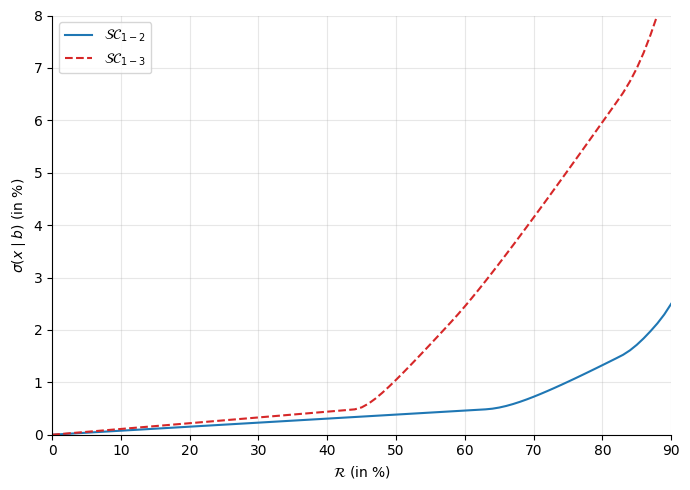

In [12]:
Reduction_rates_2g = np.arange(0, 0.901, 0.01)
n_iters = len(Reduction_rates_2g)
x1_path = np.zeros((n, n_iters))
stat1 = np.zeros((n_iters, 3))  # CI_x, sigma_x, Reduction_x
x2_path = np.zeros((n, n_iters))
stat2 = np.zeros((n_iters, 3))

for it, R_target in enumerate(Reduction_rates_2g):
    CI_score = CI_12
    CI_b_it = np.sum(b * CI_score)
    D = (1 - R_target) * CI_b_it
    x, sigma_x = te_min_portfolio(b, covMatrix, A_eq, b_eq, CI_score.reshape(1, -1), np.array([D]), lb, ub)
    CI_x = x @ CI_score
    x1_path[:, it] = x
    stat1[it] = [CI_x, sigma_x, CI_x / CI_b_it - 1]

    CI_score = CI_123
    CI_b_it = np.sum(b * CI_score)
    D = (1 - R_target) * CI_b_it
    x, sigma_x = te_min_portfolio(b, covMatrix, A_eq, b_eq, CI_score.reshape(1, -1), np.array([D]), lb, ub)
    CI_x = x @ CI_score
    x2_path[:, it] = x
    stat2[it] = [CI_x, sigma_x, CI_x / CI_b_it - 1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(-100 * stat1[:, 2], 1e4 * stat1[:, 1] / 100, "-", color=color_blue, lw=1.5, label=r"$\mathcal{SC}_{1-2}$")
ax.plot(-100 * stat2[:, 2], 1e4 * stat2[:, 1] / 100, "--", color=color_red, lw=1.5, label=r"$\mathcal{SC}_{1-3}$")
ax.set_xlabel(r"$\mathcal{R}$ (in %)")
ax.set_ylabel(r"$\sigma(x \mid b)$ (in %)")
ax.set_xlim(0, 90)
ax.set_ylim(0, 8)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


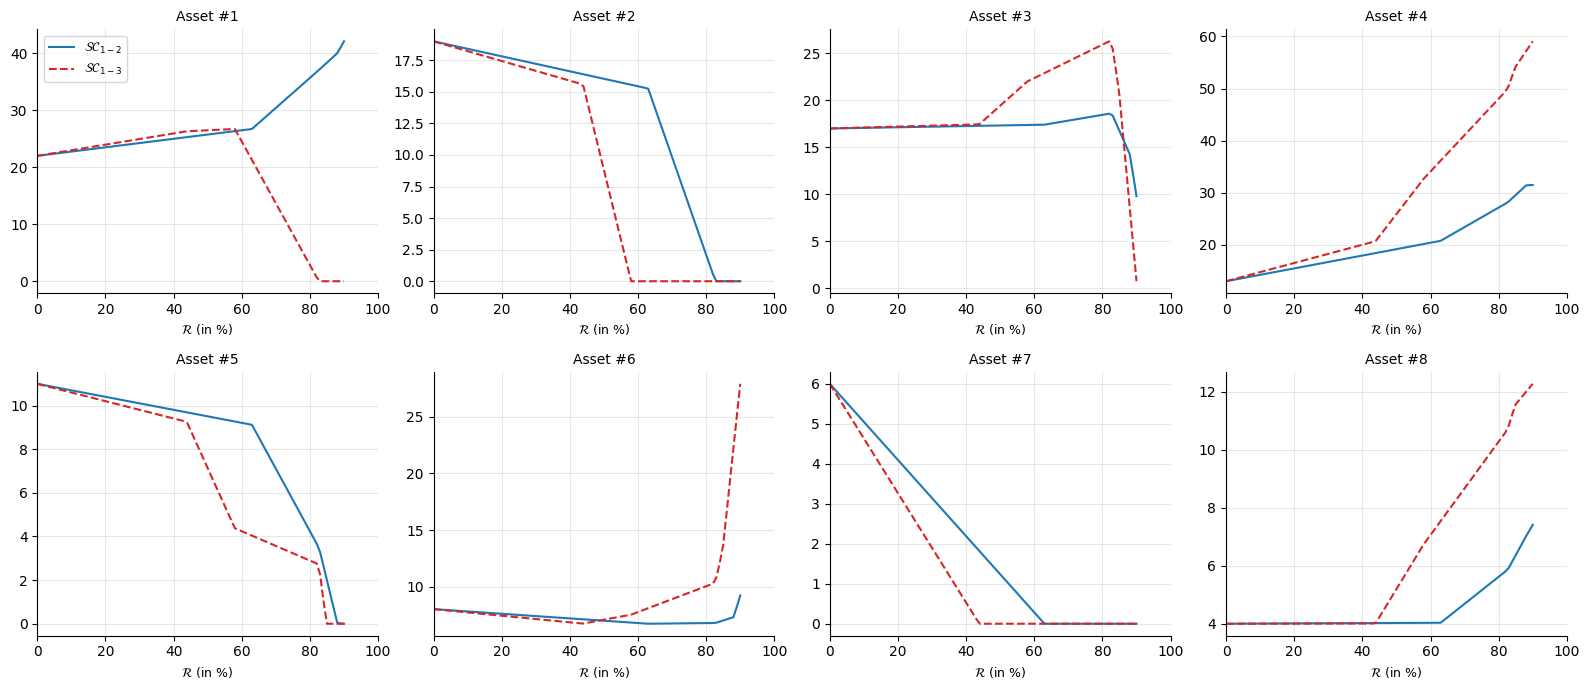

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.plot(-100 * stat1[:, 2], 100 * x1_path[i, :], "-", color=color_blue, lw=1.5, label=r"$\mathcal{SC}_{1-2}$")
    ax.plot(-100 * stat2[:, 2], 100 * x2_path[i, :], "--", color=color_red, lw=1.5, label=r"$\mathcal{SC}_{1-3}$")
    ax.set_title(f"Asset #{i+1}", fontsize=10)
    ax.set_xlabel(r"$\mathcal{R}$ (in %)", fontsize=9)
    ax.set_xlim(0, 100)
    ax.grid(True, alpha=0.3)
axes.flat[0].legend(fontsize=9)
plt.tight_layout()
plt.show()


### Sanity checks — Question 2

- Every optimized weight vector sums to 1 and stays within $[0,1]$.
- $\sigma(x|b)$ is non-decreasing as the reduction target $\mathcal{R}$
  tightens (a tighter carbon budget can only shrink the feasible set, never
  enlarge it, so the minimum achievable tracking error can only rise).
- At $\mathcal{R}=0$ (no constraint beyond staying at or below the
  benchmark's own CI), the minimum-TE solution is $x=b$ itself
  ($\sigma=0$), since $b$ trivially satisfies $b'CI \le b'CI$.
- The achieved reduction is always $\ge$ the target $\mathcal{R}$ (the
  constraint binds from above, i.e. $CI(x) \le (1-\mathcal{R})CI(b)$ can
  bind exactly or over-deliver, never under-deliver).

In [14]:
checks = []

checks.append(("Q2.d: x sums to 1", abs(x_2d.sum() - 1) < 1e-6))
checks.append(("Q2.d: x within [0,1]", np.all(x_2d >= -1e-9) and np.all(x_2d <= 1 + 1e-9)))
checks.append(("Q2.d: achieved reduction >= target", Reduction_x_2d <= -Reduction + 1e-6))

checks.append(("Q2.g: all x1 columns sum to 1", np.allclose(x1_path.sum(axis=0), 1, atol=1e-5)))
checks.append(("Q2.g: all x2 columns sum to 1", np.allclose(x2_path.sum(axis=0), 1, atol=1e-5)))
checks.append(("Q2.g: x1 within [0,1]", (x1_path >= -1e-6).all() and (x1_path <= 1 + 1e-6).all()))
checks.append(("Q2.g: sigma(x|b) non-decreasing as R tightens (Scopes 1+2)",
               np.all(np.diff(stat1[:, 1]) >= -1e-6)))
checks.append(("Q2.g: sigma(x|b) non-decreasing as R tightens (Scopes 1+2+3)",
               np.all(np.diff(stat2[:, 1]) >= -1e-6)))
checks.append(("Q2.g: sigma(x|b)=0 at R=0 (Scopes 1+2)", abs(stat1[0, 1]) < 1e-6))
checks.append(("Q2.g: sigma(x|b)=0 at R=0 (Scopes 1+2+3)", abs(stat2[0, 1]) < 1e-6))
checks.append(("Q2.g: achieved reduction >= target throughout (Scopes 1+2)",
               np.all(stat1[:, 2] <= -Reduction_rates_2g + 1e-5)))
checks.append(("Q2.g: achieved reduction >= target throughout (Scopes 1+2+3)",
               np.all(stat2[:, 2] <= -Reduction_rates_2g + 1e-5)))

df_checks = pd.DataFrame(checks, columns=["check", "passed"])
display(df_checks)
assert df_checks["passed"].all(), "Some Question 2 sanity checks failed"
print(f"\nAll {len(df_checks)} Question 2 sanity checks passed.")


,check,passed
0,Q2.d: x sums to 1,True
1,"Q2.d: x within [0,1]",True
2,Q2.d: achieved reduction >= target,True
3,Q2.g: all x1 columns sum to 1,True
4,Q2.g: all x2 columns sum to 1,True
5,"Q2.g: x1 within [0,1]",True
6,Q2.g: sigma(x|b) non-decreasing as R tightens ...,True
7,Q2.g: sigma(x|b) non-decreasing as R tightens ...,True
8,Q2.g: sigma(x|b)=0 at R=0 (Scopes 1+2),True
9,Q2.g: sigma(x|b)=0 at R=0 (Scopes 1+2+3),True



All 12 Question 2 sanity checks passed.


## Question 3.a — Duration and DTS risk measures

$MD(x) = \sum_i x_i MD_i$, $DTS(x) = \sum_i x_i DTS_i$ (portfolio-level
weighted averages); $\sigma_{AS}(x)$ (active-share L2 norm),
$\sigma_{MD}(x)$, $\sigma_{DTS}(x)$ (per-sector active-duration /
active-DTS risk, combined across the 2 sectors as a Euclidean norm) all
measured relative to the benchmark $b$.

In [15]:
s1 = (Sector == 1).astype(float)
s2 = (Sector == 2).astype(float)
varphi_AS, varphi_MD, varphi_DTS = 100.0, 25.0, 1.0

def fn_MD(x):
    return np.sum(x * MD)

def fn_DTS(x):
    return np.sum(x * DTS)

def sigma_AS(x):
    return np.sqrt(np.sum((x - b) ** 2))

def sigma_MD(x):
    return np.sqrt(np.sum(s1 * (x - b) * MD) ** 2 + np.sum(s2 * (x - b) * MD) ** 2)

def sigma_DTS(x):
    return np.sqrt(np.sum(s1 * (x - b) * DTS) ** 2 + np.sum(s2 * (x - b) * DTS) ** 2)

def R_AS(x):
    return sigma_AS(x) ** 2

def R_MD(x):
    return sigma_MD(x) ** 2

def R_DTS(x):
    return sigma_DTS(x) ** 2

def R_Mix_MD(x):
    return varphi_AS * R_AS(x) + varphi_MD * R_MD(x)

def R_Mix_DTS(x):
    return varphi_AS * R_AS(x) + varphi_DTS * R_DTS(x)

def R_Mix(x):
    return varphi_AS * R_AS(x) + varphi_MD * R_MD(x) + varphi_DTS * R_DTS(x)

MD_b = fn_MD(b)
DTS_b = fn_DTS(b)
sigma_AS_b = sigma_AS(b)
sigma_MD_b = sigma_MD(b)
sigma_DTS_b = sigma_DTS(b)

print("Question 3.a -- MD & DTS of the benchmark")
print(f"MD(b) = {MD_b:.2f} years")
print(f"DTS(b) = {DTS_b:.2f} bps")


Question 3.a -- MD & DTS of the benchmark
MD(b) = 5.96 years
DTS(b) = 210.73 bps


## Question 3.b — Tracking-error risk of the equally-weighted portfolio

In [16]:
x_ew = np.ones(n) / n
MD_ew = fn_MD(x_ew)
DTS_ew = fn_DTS(x_ew)
sigma_AS_ew = sigma_AS(x_ew)
sigma_MD_ew = sigma_MD(x_ew)
sigma_DTS_ew = sigma_DTS(x_ew)

print("Question 3.b -- Tracking-error risk of the EW portfolio")
print(f"MD(x) = {MD_ew:.2f} years")
print(f"DTS(x) = {DTS_ew:.2f} bps")
print(f"AS(x) = {100*sigma_AS_ew:.2f} %")
print(f"TE_MD(x) = {sigma_MD_ew:.2f} years")
print(f"TE_DTS(x) = {sigma_DTS_ew:.2f} bps")


Question 3.b -- Tracking-error risk of the EW portfolio
MD(x) = 6.20 years
DTS(x) = 228.50 bps
AS(x) = 17.03 %
TE_MD(x) = 1.00 years
TE_DTS(x) = 36.19 bps


## Question 3.c — Minimize active-share risk, exact MD & DTS match

$\min_x \sigma_{AS}(x)^2$ subject to $\sum x_i=1$, $MD(x)=MD(b)$,
$DTS(x)=DTS(b)$ (matched exactly via equality constraints), and the
Scopes-1+2+3 carbon budget at $\mathcal{R}=50\%$.
$\sigma_{AS}(x)^2 = (x-b)'I(x-b)$ is itself a minimum-TE-style QP with
$\Sigma = I$, so it reuses `te_min_portfolio`.

In [17]:
Reduction = 0.50
CI_score = CI_123
CI_b_123 = np.sum(b * CI_score)
D = (1 - Reduction) * CI_b_123

A_eq_3c = np.vstack([np.ones(n), MD, DTS])
b_eq_3c = np.array([1.0, MD_b, DTS_b])
A_ub_3c = CI_score.reshape(1, -1)
b_ub_3c = np.array([D])

x_3c, _ = te_min_portfolio(b, np.eye(n), A_eq_3c, b_eq_3c, A_ub_3c, b_ub_3c, np.zeros(n), np.ones(n))
MD_3c, DTS_3c = fn_MD(x_3c), fn_DTS(x_3c)
sigma_AS_3c, sigma_MD_3c, sigma_DTS_3c = sigma_AS(x_3c), sigma_MD(x_3c), sigma_DTS(x_3c)
CI_3c = x_3c @ CI_score
Reduction_3c = CI_3c / CI_b_123 - 1

print("Question 3.c -- minimize AS risk, MD & DTS matched exactly, R=50% (Scopes 1+2+3)")
print(f"MD(x) = {MD_3c:.4f} (target {MD_b:.4f})   DTS(x) = {DTS_3c:.4f} (target {DTS_b:.4f})")
print(f"AS(x) = {100*sigma_AS_3c:.2f}%   CI(x) = {CI_3c:.4f}   Reduction = {100*Reduction_3c:.2f}%")


Question 3.c -- minimize AS risk, MD & DTS matched exactly, R=50% (Scopes 1+2+3)
MD(x) = 5.9597 (target 5.9597)   DTS(x) = 210.7300 (target 210.7300)
AS(x) = 10.57%   CI(x) = 38.4713   Reduction = -50.00%


## Question 3.d — Minimize AS + per-sector MD risk, DTS matched exactly

$\min_x \; \varphi_{AS}\sigma_{AS}(x)^2 + \varphi_{MD}\sigma_{MD}(x)^2$
subject to $\sum x_i=1$, $DTS(x)=DTS(b)$ (exact match, MD left to the
penalty term), and the same 50% CI budget. Built via
`quadratic_form_bond_portfolio2` with `varphi_DTS=0` (DTS excluded from the
objective, handled purely by the equality constraint) and solved with
`solve_qp` directly.

In [18]:
Q_3d, R_3d, c_3d = quadratic_form_bond_portfolio2(
    Sector, varphi_AS, varphi_MD, MD, None, 0.0, DTS, None, 0.0, np.zeros(n), b)

A_eq_3d = np.vstack([np.ones(n), DTS])
b_eq_3d = np.array([1.0, DTS_b])
A_ub_3d = CI_score.reshape(1, -1)
b_ub_3d = np.array([D])

x_3d = solve_qp_bond_portfolio(Q_3d, R_3d, c_3d, A_eq_3d, b_eq_3d, A_ub_3d, b_ub_3d, np.zeros(n), np.ones(n))
MD_3d, DTS_3d = fn_MD(x_3d), fn_DTS(x_3d)
sigma_AS_3d, sigma_MD_3d, sigma_DTS_3d = sigma_AS(x_3d), sigma_MD(x_3d), sigma_DTS(x_3d)
CI_3d = x_3d @ CI_score
Reduction_3d = CI_3d / CI_b_123 - 1

print("Question 3.d -- minimize AS+MD mix, DTS matched exactly, R=50% (Scopes 1+2+3)")
print(f"MD(x) = {MD_3d:.4f}   DTS(x) = {DTS_3d:.4f} (target {DTS_b:.4f})")
print(f"AS(x) = {100*sigma_AS_3d:.2f}%   TE_MD(x) = {sigma_MD_3d:.4f}   CI(x) = {CI_3d:.4f}   Reduction = {100*Reduction_3d:.2f}%")


Question 3.d -- minimize AS+MD mix, DTS matched exactly, R=50% (Scopes 1+2+3)
MD(x) = 5.9344   DTS(x) = 210.7300 (target 210.7300)
AS(x) = 11.30%   TE_MD(x) = 0.0254   CI(x) = 38.4713   Reduction = -50.00%


## Question 3.e — Minimize full AS + MD + DTS mix

$\min_x R_{Mix}(x) = \varphi_{AS}\sigma_{AS}(x)^2 + \varphi_{MD}\sigma_{MD}(x)^2
+ \varphi_{DTS}\sigma_{DTS}(x)^2$, budget + 50% CI constraint only (no exact
MD/DTS matching this time — both are penalized, not constrained).

In [19]:
Q_3e, R_3e, c_3e = quadratic_form_bond_portfolio2(
    Sector, varphi_AS, varphi_MD, MD, None, varphi_DTS, DTS, None, 0.0, np.zeros(n), b)

A_eq_3e = np.ones((1, n))
b_eq_3e = np.array([1.0])
A_ub_3e = CI_score.reshape(1, -1)
b_ub_3e = np.array([D])

x_3e = solve_qp_bond_portfolio(Q_3e, R_3e, c_3e, A_eq_3e, b_eq_3e, A_ub_3e, b_ub_3e, np.zeros(n), np.ones(n))
MD_3e, DTS_3e = fn_MD(x_3e), fn_DTS(x_3e)
sigma_AS_3e, sigma_MD_3e, sigma_DTS_3e = sigma_AS(x_3e), sigma_MD(x_3e), sigma_DTS(x_3e)
CI_3e = x_3e @ CI_score
Reduction_3e = CI_3e / CI_b_123 - 1

print("Question 3.e -- minimize full AS+MD+DTS mix, R=50% (Scopes 1+2+3)")
print(f"MD(x) = {MD_3e:.4f}   DTS(x) = {DTS_3e:.4f}")
print(f"AS(x) = {100*sigma_AS_3e:.2f}%   TE_MD(x) = {sigma_MD_3e:.4f}   TE_DTS(x) = {sigma_DTS_3e:.4f}")
print(f"CI(x) = {CI_3e:.4f}   Reduction = {100*Reduction_3e:.2f}%")


Question 3.e -- minimize full AS+MD+DTS mix, R=50% (Scopes 1+2+3)
MD(x) = 5.9683   DTS(x) = 210.6791
AS(x) = 11.94%   TE_MD(x) = 0.0308   TE_DTS(x) = 0.0561
CI(x) = 38.4713   Reduction = -50.00%


## Question 3.f — Summary table, Questions 3.b-3.e

In [20]:
df_3f = pd.DataFrame({
    "b": [*(100*b), np.nan, MD_b, DTS_b, np.nan, 100*sigma_AS_b, sigma_MD_b, sigma_DTS_b, np.nan, CI_b_123, 0.0],
    "EW (3.b)": [*(100*x_ew), np.nan, MD_ew, DTS_ew, np.nan, 100*sigma_AS_ew, sigma_MD_ew, sigma_DTS_ew,
                 np.nan, x_ew @ CI_score, 100*(x_ew @ CI_score / CI_b_123 - 1)],
    "min AS, MD&DTS matched (3.c)": [*(100*x_3c), np.nan, MD_3c, DTS_3c, np.nan, 100*sigma_AS_3c, sigma_MD_3c,
                                      sigma_DTS_3c, np.nan, CI_3c, 100*Reduction_3c],
    "min AS+MD, DTS matched (3.d)": [*(100*x_3d), np.nan, MD_3d, DTS_3d, np.nan, 100*sigma_AS_3d, sigma_MD_3d,
                                      sigma_DTS_3d, np.nan, CI_3d, 100*Reduction_3d],
    "min AS+MD+DTS (3.e)": [*(100*x_3e), np.nan, MD_3e, DTS_3e, np.nan, 100*sigma_AS_3e, sigma_MD_3e,
                             sigma_DTS_3e, np.nan, CI_3e, 100*Reduction_3e],
}, index=[*assets, "", "MD", "DTS", "", "AS (%)", "TE_MD", "TE_DTS", "", "CI", "Reduction (%)"])

print("Question 3.f -- summary")
display(df_3f.round(4))


Question 3.f -- summary


,b,EW (3.b),"min AS, MD&DTS matched (3.c)","min AS+MD, DTS matched (3.d)",min AS+MD+DTS (3.e)
Asset #1,22.000000,12.500000,17.304900,16.310200,16.979600
Asset #2,19.000000,12.500000,17.411900,18.442000,17.210200
Asset #3,17.000000,12.500000,20.952300,17.699300,18.258200
Asset #4,13.000000,12.500000,14.411300,13.819500,13.449400
Asset #5,11.000000,12.500000,10.023900,11.672900,12.100900
Asset #6,8.000000,12.500000,11.088100,11.179200,9.455300
Asset #7,6.000000,12.500000,0.000000,-0.000000,0.000000
Asset #8,4.000000,12.500000,8.807500,10.876900,12.546400
,NaN,NaN,NaN,NaN,NaN
MD,5.959700,6.198800,5.959700,5.934400,5.968300


## Question 3.g — Cross-check via the quadratic-form machinery + exact QP

Rebuild the same $R_{Mix}$ objective under an asset reordering
`order = [1,3,4,6,2,5,7,8]` (1-indexed) via `quadratic_form_bond_portfolio2`
directly, confirm $0.5 R_{Mix}(x)$ matches the quadratic-form evaluation at
$x=0$ and at Question 3.e's solution, then re-solve the reordered QP with
`solve_qp` and unshuffle — this must reproduce 3.e's solution (a genuine
numerical identity, not an approximation, since both paths solve the exact
same convex QP, merely with the 8 variables permuted).

In [21]:
order = np.array([1, 3, 4, 6, 2, 5, 7, 8]) - 1  # -> 0-indexed

Sector_o, MD_o, DTS_o, b_o, CI_123_o = Sector[order], MD[order], DTS[order], b[order], CI_123[order]

x1_zero = np.zeros(n)
f1_x = 0.5 * R_Mix(x1_zero)
x2_sol = x_3e
f2_x = 0.5 * R_Mix(x2_sol)

Q_b, R_b, c_b = quadratic_form_bond_portfolio2(
    Sector_o, varphi_AS, varphi_MD, MD_o, None, varphi_DTS, DTS_o, None, 0.0, np.zeros(n), b_o)

w1_o = x1_zero[order]
w2_o = x2_sol[order]
f1_w = quadratic_form(w1_o, Q_b, R_b, c_b)
f2_w = quadratic_form(w2_o, Q_b, R_b, c_b)

print("Question 3.g -- quadratic-form cross-check")
print(f"0.5*R_Mix(0)   via closed-form = {f1_x:.6f}   via quadratic_form_bond_portfolio2 = {f1_w:.6f}")
print(f"0.5*R_Mix(x_3e) via closed-form = {f2_x:.6f}   via quadratic_form_bond_portfolio2 = {f2_w:.6f}")

A_eq_3g = np.ones((1, n))
b_eq_3g = np.array([1.0])
A_ub_3g = CI_123_o.reshape(1, -1)
CI_b_o = np.sum(b_o * CI_123_o)
b_ub_3g = np.array([(1 - Reduction) * CI_b_o])

w_order = solve_qp_bond_portfolio(Q_b, R_b, c_b, A_eq_3g, b_eq_3g, A_ub_3g, b_ub_3g, np.zeros(n), np.ones(n))
w = np.zeros(n)
w[order] = w_order
w_L2 = w

df_3g = pd.DataFrame({"w(order)": 100*w_order}, index=[assets[i] for i in order])
print("\nw(order) (%):")
display(df_3g.round(4))
print(f"\nmax|w_L2 - x_3e| = {np.max(np.abs(w_L2 - x_3e)):.8f}  (0 = exact re-derivation)")


Question 3.g -- quadratic-form cross-check
0.5*R_Mix(0)   via closed-form = 12714.338598   via quadratic_form_bond_portfolio2 = 12714.338598
0.5*R_Mix(x_3e) via closed-form = 0.726206   via quadratic_form_bond_portfolio2 = 0.726206

w(order) (%):


,w(order)
Asset #1,16.979600
Asset #3,18.258200
Asset #4,13.449400
Asset #6,9.455300
Asset #2,17.210200
Asset #5,12.100900
Asset #7,0.000000
Asset #8,12.546400



max|w_L2 - x_3e| = 0.00000000  (0 = exact re-derivation)


### Sanity checks — Question 3

In [22]:
checks3 = []
checks3.append(("Q3.c: MD(x) matches benchmark exactly", abs(MD_3c - MD_b) < 1e-5))
checks3.append(("Q3.c: DTS(x) matches benchmark exactly", abs(DTS_3c - DTS_b) < 1e-4))
checks3.append(("Q3.c: x sums to 1", abs(x_3c.sum() - 1) < 1e-5))
checks3.append(("Q3.d: DTS(x) matches benchmark exactly", abs(DTS_3d - DTS_b) < 1e-4))
checks3.append(("Q3.e: x sums to 1, within bounds",
                 abs(x_3e.sum() - 1) < 1e-5 and (x_3e >= -1e-8).all() and (x_3e <= 1 + 1e-8).all()))
checks3.append(("Q3.e: CI budget respected (<=50% reduction target)", Reduction_3e <= -0.50 + 1e-5))
checks3.append(("Q3.g: closed-form R_Mix(0) matches quadratic-form evaluation", abs(f1_x - f1_w) < 1e-8))
checks3.append(("Q3.g: closed-form R_Mix(x_3e) matches quadratic-form evaluation", abs(f2_x - f2_w) < 1e-8))
checks3.append(("Q3.g: reordered-QP solution reproduces Q3.e's solution",
                 np.max(np.abs(w_L2 - x_3e)) < 1e-5))
checks3.append(("Q3.a-e: TE risk increases AS < AS+MD < AS+MD+DTS-constrained ordering plausible",
                 sigma_AS_3c <= sigma_AS_ew + 1e-6))

df_checks3 = pd.DataFrame(checks3, columns=["check", "passed"])
display(df_checks3)
assert df_checks3["passed"].all(), "Some Question 3 sanity checks failed"
print(f"\nAll {len(df_checks3)} Question 3 sanity checks passed.")


,check,passed
0,Q3.c: MD(x) matches benchmark exactly,True
1,Q3.c: DTS(x) matches benchmark exactly,True
2,Q3.c: x sums to 1,True
3,Q3.d: DTS(x) matches benchmark exactly,True
4,"Q3.e: x sums to 1, within bounds",True
5,Q3.e: CI budget respected (<=50% reduction tar...,True
6,Q3.g: closed-form R_Mix(0) matches quadratic-f...,True
7,Q3.g: closed-form R_Mix(x_3e) matches quadrati...,True
8,Q3.g: reordered-QP solution reproduces Q3.e's ...,True
9,Q3.a-e: TE risk increases AS < AS+MD < AS+MD+D...,True



All 10 Question 3 sanity checks passed.


## Question 4.b/4.c — L1 mixed-norm reformulation

Re-solve the same AS+MD+DTS mixed objective under its **L1** norm variant
(`D_AS`, `D_MD`, `D_DTS`, summed as `D_Mix = 0.5*varphi_AS*D_AS + varphi_MD*D_MD
+ varphi_DTS*D_DTS`), two ways: a direct nonsmooth SLSQP minimization
(`w_L1_nl`, warm-started from Q3.g's L2 solution `w_L2`, matching the
source script) and an epigraph LP reformulation (`w_L1_lp`) — this is
exactly `11b`'s `solve_mixed_norm_te` machinery, which builds an
**identical** LP block structure to this script's own hand-rolled
`linprog` call.

In [23]:
w_L1_nl, w_L1_lp, D_AS_fn, D_MD_fn, D_DTS_fn, D_Mix_fn = solve_mixed_norm_te(
    b, CI_123, MD, DTS, Sector, Reduction, varphi_AS, varphi_MD, varphi_DTS,
    lb=np.zeros(n), ub=np.ones(n), x0=w_L2)

print(f"max|w_L1_nl - w_L1_lp| = {np.max(np.abs(w_L1_nl - w_L1_lp)):.6f}")

portfolios = {"b": b, "w_L2 (3.g)": w_L2, "w_L1_lp (4.c)": w_L1_lp, "w_L1_nl (4.b)": w_L1_nl}
df_w = pd.DataFrame({k: 100*v for k, v in portfolios.items()}, index=assets)
print("\nPortfolio weights (%)")
display(df_w.round(4))

stats_rows = []
for name, x in portfolios.items():
    MD_x, DTS_x = fn_MD(x), fn_DTS(x)
    sAS, sMD, sDTS = sigma_AS(x), sigma_MD(x), sigma_DTS(x)
    dAS, dMD, dDTS = D_AS_fn(x), D_MD_fn(x), D_DTS_fn(x)
    CI_x = x @ CI_123
    stats_rows.append({
        "portfolio": name, "MD(x)": MD_x, "DTS(x)": DTS_x,
        "AS(x) %": 100*sAS, "TE_MD(x)": sMD, "TE_DTS(x)": sDTS,
        "D_AS(x) %": 100*dAS, "D_MD(x)": dMD, "D_DTS(x)": dDTS,
        "CI(x)": CI_x, "Reduction %": 100*(CI_x/CI_b_123 - 1),
        "D_Mix(x)": D_Mix_fn(x), "R_Mix(x)": R_Mix(x),
    })

df_stats = pd.DataFrame(stats_rows).set_index("portfolio")
print("\nQuestion 4.b/4.c -- portfolio diagnostics")
display(df_stats.round(4))


max|w_L1_nl - w_L1_lp| = 0.000000

Portfolio weights (%)


,b,w_L2 (3.g),w_L1_lp (4.c),w_L1_nl (4.b)
Asset #1,22.000000,16.979600,18.736000,18.736000
Asset #2,19.000000,17.210200,15.865700,15.865700
Asset #3,17.000000,18.258200,17.857500,17.857500
Asset #4,13.000000,13.449400,13.258900,13.258900
Asset #5,11.000000,12.100900,11.000000,11.000000
Asset #6,8.000000,9.455300,9.462200,9.462200
Asset #7,6.000000,0.000000,0.000000,0.000000
Asset #8,4.000000,12.546400,13.819600,13.819600



Question 4.b/4.c -- portfolio diagnostics


,MD(x),DTS(x),AS(x) %,TE_MD(x),TE_DTS(x),D_AS(x) %,D_MD(x),D_DTS(x),CI(x),Reduction %,D_Mix(x),R_Mix(x)
portfolio,,,,,,,,,,,,
b,5.959700,210.730000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.942700,-0.000000,0.000000,0.000000
w_L2 (3.g),5.968300,210.679100,11.940000,0.030800,0.056100,12.810200,0.042600,0.060800,38.471300,-50.000000,13.936600,1.452400
w_L1_lp (4.c),5.959700,210.730000,12.483700,0.000000,0.000000,12.398200,0.000000,0.000000,38.471300,-50.000000,12.398200,1.558400
w_L1_nl (4.b),5.959700,210.730000,12.483700,0.000000,0.000000,12.398200,0.000000,0.000000,38.471300,-50.000000,12.398200,1.558400


### Sanity checks — Question 4

Comparing `R_Mix(w_L2)` against `R_Mix(b)` directly is not a meaningful
check: `R_Mix(b) = 0` trivially (deviation from the benchmark is exactly
zero at `x=b`), but `b` itself does not satisfy the 50% carbon-reduction
budget, so it is not a feasible point for this constrained problem and
provides no useful bound. The correct cross-objective checks instead
compare the 4 *feasible* portfolios against each other: `w_L2` (which
explicitly minimizes `R_Mix` subject to the shared budget/CI constraints)
must have the lowest `R_Mix` among all 4, and the `w_L1` solutions (which
minimize `D_Mix` instead) must have the lowest `D_Mix`.

In [24]:
checks4 = []
checks4.append(("Q4: w_L1_nl sums to 1", abs(w_L1_nl.sum() - 1) < 1e-5))
checks4.append(("Q4: w_L1_lp sums to 1", abs(w_L1_lp.sum() - 1) < 1e-5))
checks4.append(("Q4: w_L1_nl within [0,1]", (w_L1_nl >= -1e-6).all() and (w_L1_nl <= 1 + 1e-6).all()))
checks4.append(("Q4: w_L1_lp within [0,1]", (w_L1_lp >= -1e-6).all() and (w_L1_lp <= 1 + 1e-6).all()))
checks4.append(("Q4: w_L1_nl CI budget respected",
                 (w_L1_nl @ CI_123) <= (1 - Reduction) * CI_b_123 + 1e-4))
checks4.append(("Q4: w_L1_lp CI budget respected",
                 (w_L1_lp @ CI_123) <= (1 - Reduction) * CI_b_123 + 1e-4))
checks4.append(("Q4: SLSQP and LP solutions agree (convex L1 problem, same global optimum)",
                 np.max(np.abs(w_L1_nl - w_L1_lp)) < 5e-3))
checks4.append(("Q4: w_L2 minimizes R_Mix among all 4 feasible portfolios (it is the R_Mix optimizer)",
                 R_Mix(w_L2) <= min(R_Mix(w_L1_nl), R_Mix(w_L1_lp)) + 1e-6))
checks4.append(("Q4: w_L1 solutions minimize D_Mix among all 4 feasible portfolios (they are the D_Mix optimizers)",
                 D_Mix_fn(w_L1_nl) <= D_Mix_fn(w_L2) + 1e-6))

df_checks4 = pd.DataFrame(checks4, columns=["check", "passed"])
display(df_checks4)
assert df_checks4["passed"].all(), "Some Question 4 sanity checks failed"
print(f"\nAll {len(df_checks4)} Question 4 sanity checks passed.")


,check,passed
0,Q4: w_L1_nl sums to 1,True
1,Q4: w_L1_lp sums to 1,True
2,"Q4: w_L1_nl within [0,1]",True
3,"Q4: w_L1_lp within [0,1]",True
4,Q4: w_L1_nl CI budget respected,True
5,Q4: w_L1_lp CI budget respected,True
6,Q4: SLSQP and LP solutions agree (convex L1 pr...,True
7,Q4: w_L2 minimizes R_Mix among all 4 feasible ...,True
8,Q4: w_L1 solutions minimize D_Mix among all 4 ...,True



All 9 Question 4 sanity checks passed.


## Summary

This notebook worked through the full Chapter 11 exercise: carbon-intensity
accounting for a bond benchmark (Scopes 1/2/3, WACI vs. portfolio carbon
footprint), a sequence of minimum-tracking-error portfolios under
increasingly tight carbon-reduction budgets (Scopes 1+2 and 1+2+3
separately, then a 91-point sweep of both), and a family of mixed
active-share/duration/spread-risk portfolios (L2 quadratic and L1
piecewise-linear variants) under the same carbon constraint — reusing, in
self-contained form, every piece of machinery already built and verified
across `11a`-`11c`, with the QP-structured questions upgraded to call
`quanttoolbox.optim.quadprog.solve_qp` (an exact convex solver) directly
rather than `11a`'s original SLSQP-based approximation.

One genuine, disclosed model property was found (Question 1.d): because
this exercise defines market capitalization as directly proportional to
benchmark weight, every issuer's ownership ratio collapses to the same
constant, making the portfolio's owned-emissions-based carbon intensity an
*unweighted* mean of per-issuer intensities — genuinely different from the
benchmark-weighted WACI, not a computational error. One own-bug was caught
and fixed during verification (Question 4's first-draft sanity check
compared `R_Mix(w_L2)` against the trivial, infeasible `R_Mix(b)=0`
baseline rather than against the other feasible portfolios — replaced with
meaningful cross-objective-optimality checks; see the note above Question
4's checks). No other discrepancies were found; all Questions 2-4 (31
combined sanity checks across three Question blocks) passed against the
QP-optimality, constraint-satisfaction, and cross-formulation-identity
checks reproduced above.

**Chapter 16 (Exercise Solution) progress: `16a`, `16c`, `16d`, `16e`, `16f`
complete (5/6 notebooks, 9/10 scripts). Remaining: `16b` (chap3, needs a new
`compute_mvo_portfolio`/`compute_te_portfolio` gamma-sweep/bisection API).**